# Pingviinid

In [148]:
!pip3 install duckdb
!pip3 install shap
!pip install streamlit

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
zsh:1: command not found: pip


In [56]:
import seaborn as sns
import duckdb

In [3]:
penguin = sns.load_dataset("penguins")
penguin

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


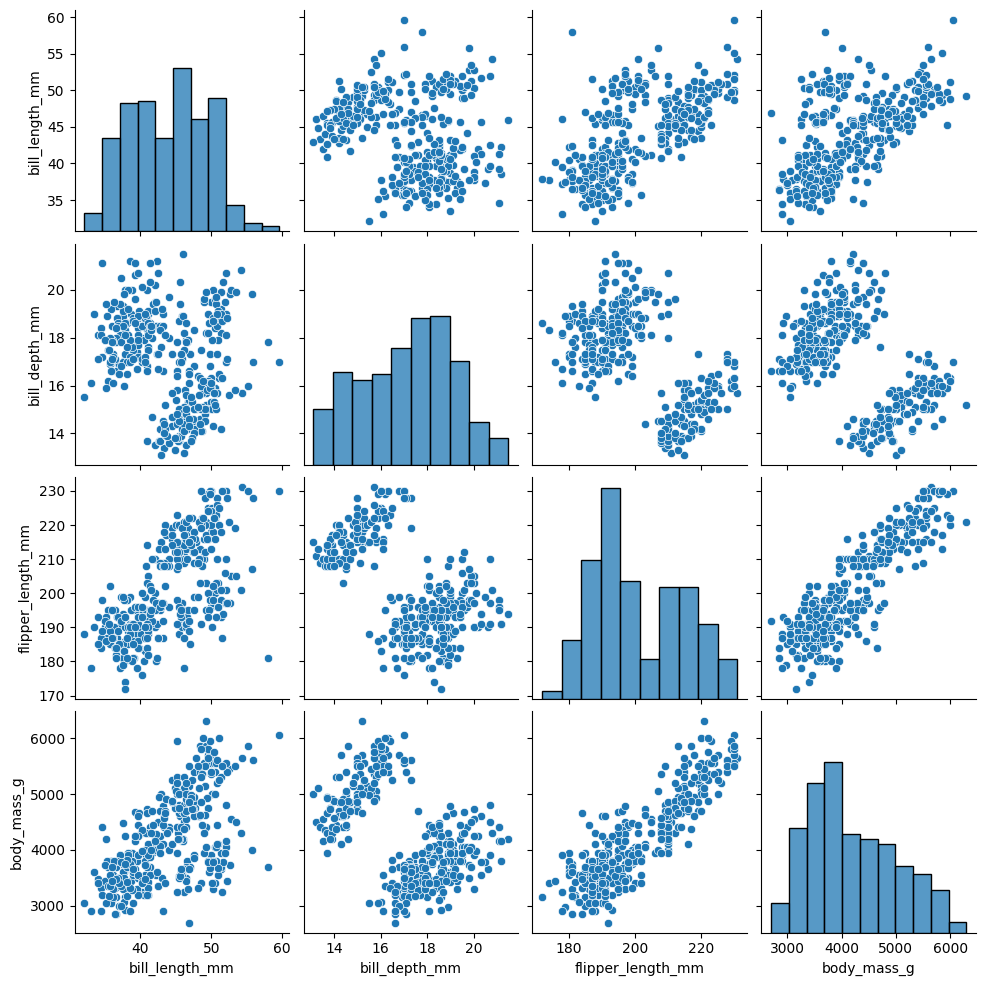

In [4]:
sns.pairplot(penguin)

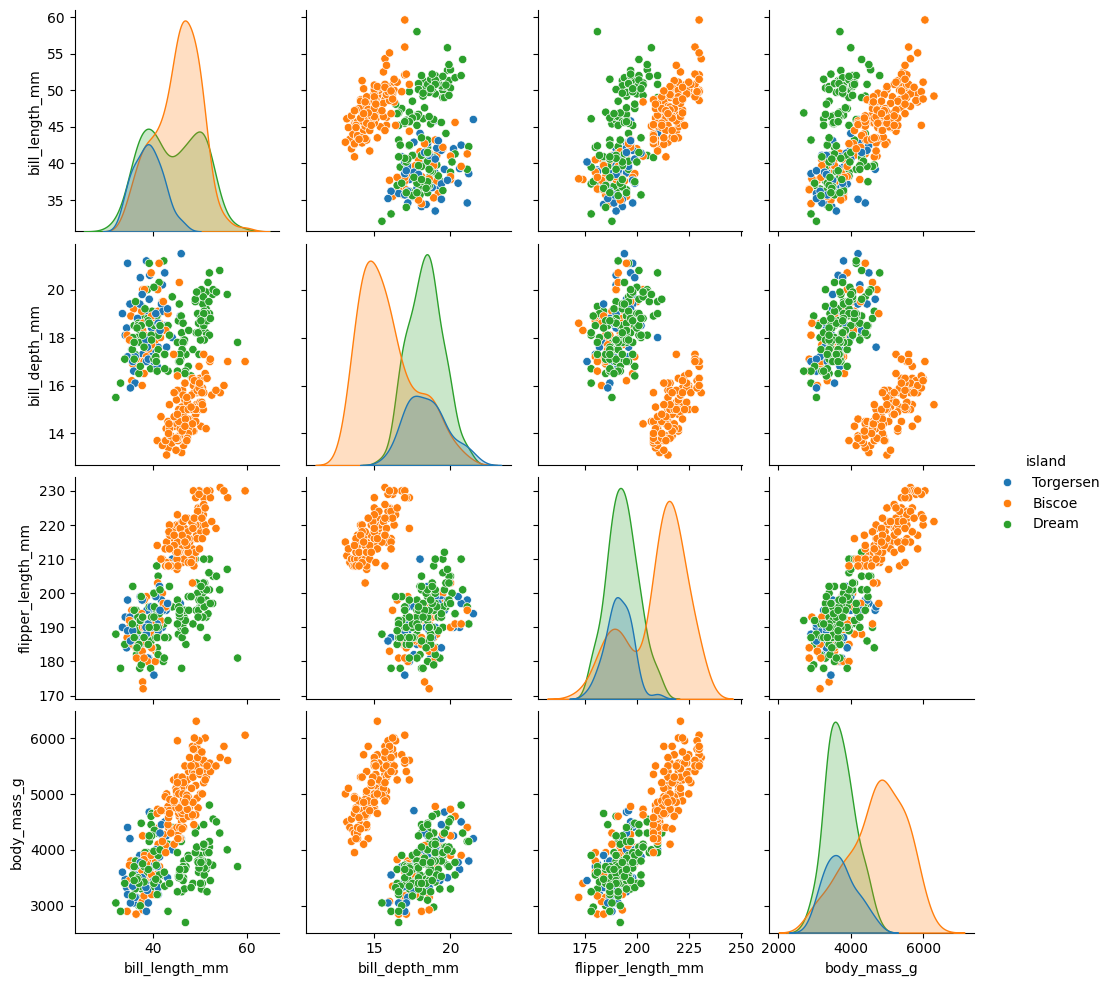

In [5]:
sns.pairplot(penguin, hue="island")

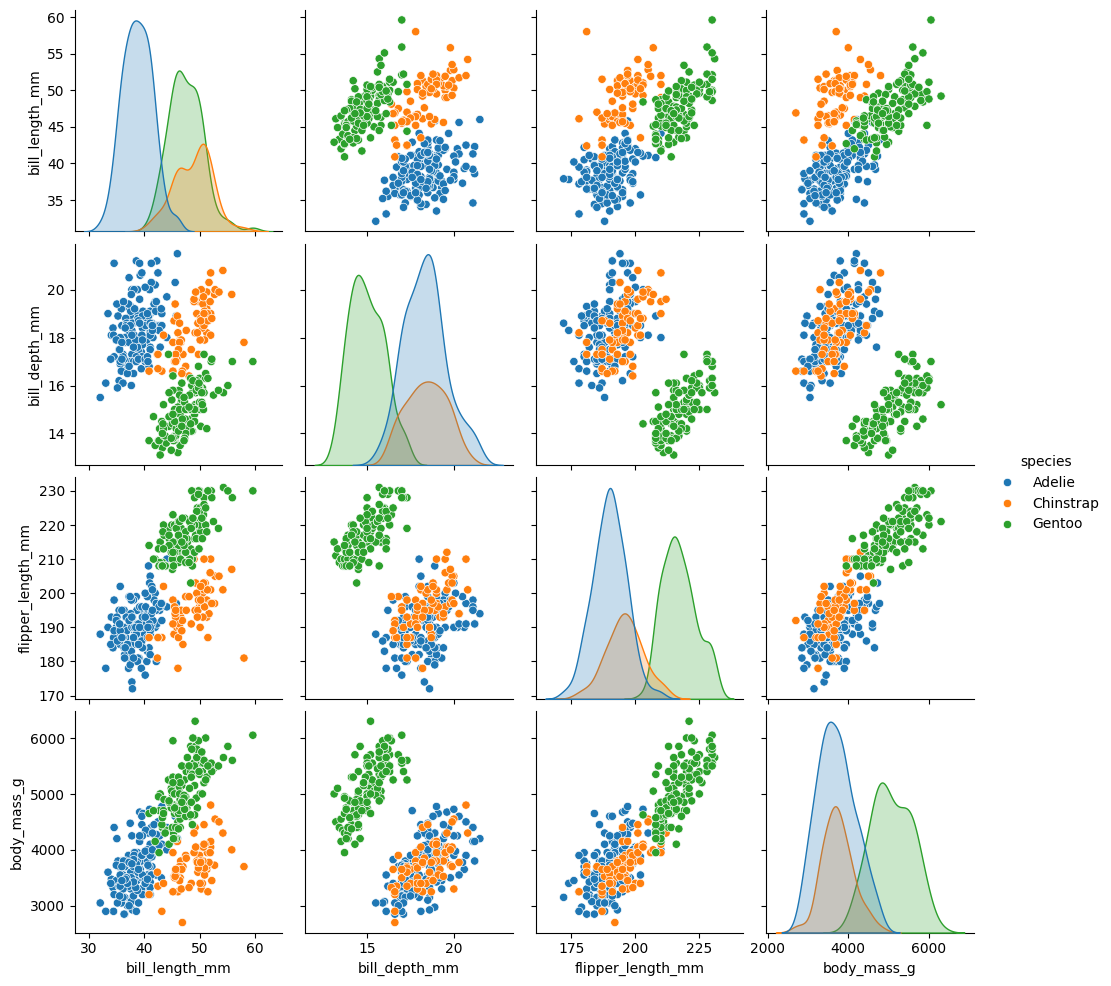

In [6]:
sns.pairplot(penguin, hue="species")

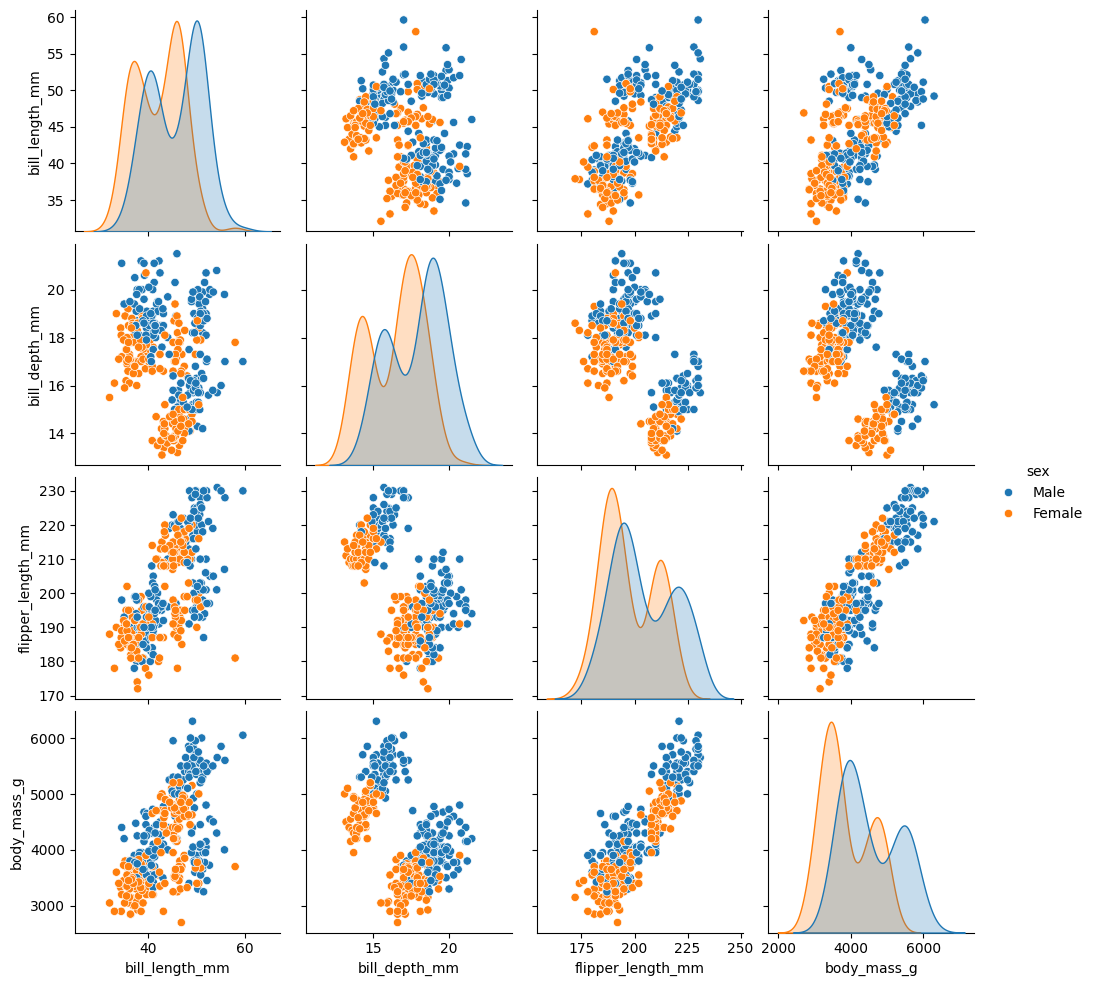

In [14]:
sns.pairplot(penguin, hue="sex")

<Axes: xlabel='count', ylabel='island'>

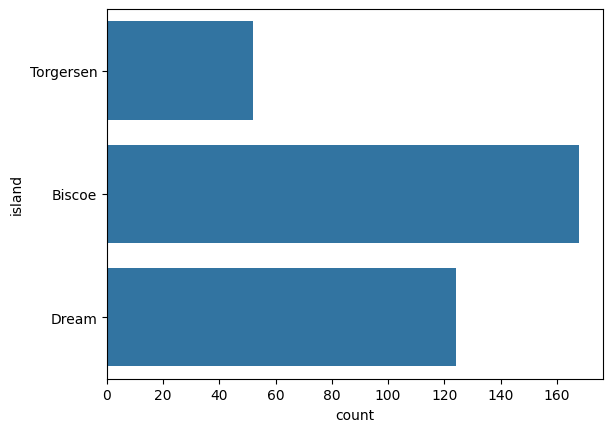

In [9]:
sns.countplot(penguin, y="island")

<Axes: xlabel='count', ylabel='species'>

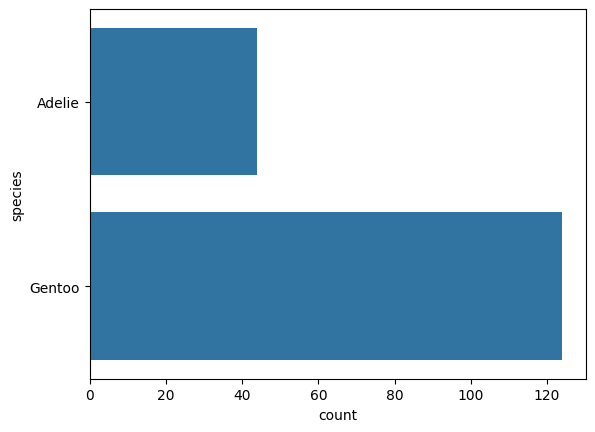

In [26]:
sns.countplot(penguin[penguin["island"] == "Biscoe"], y="species")

<Axes: xlabel='count', ylabel='species'>

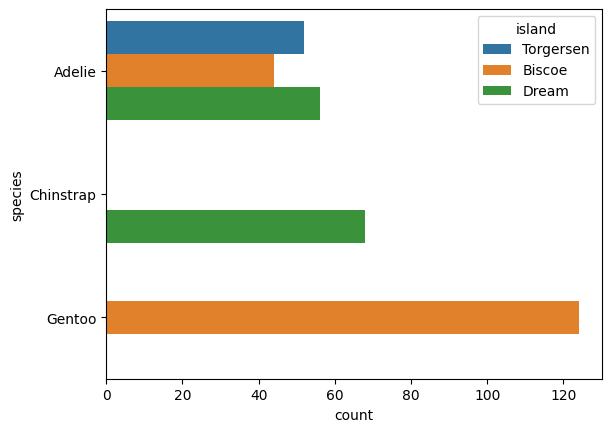

In [12]:
sns.countplot(penguin, y="species", hue="island")

<Axes: xlabel='body_mass_g', ylabel='species'>

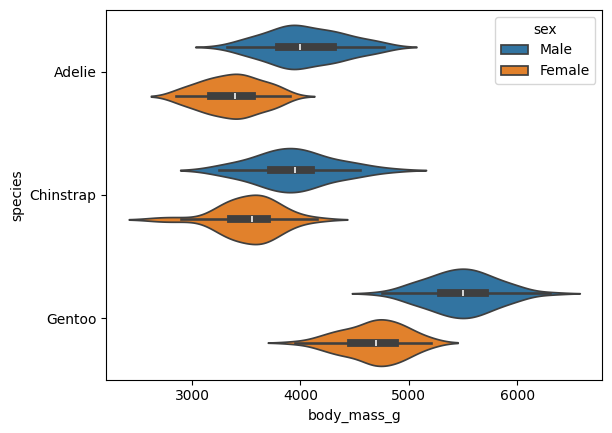

In [17]:
sns.violinplot(penguin, x="body_mass_g", y="species", hue="sex")

<Axes: xlabel='body_mass_g', ylabel='island'>

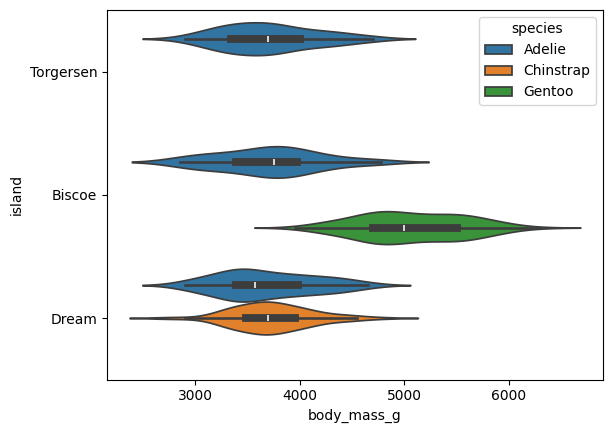

In [19]:
sns.violinplot(penguin, x="body_mass_g", y="island", hue="species")

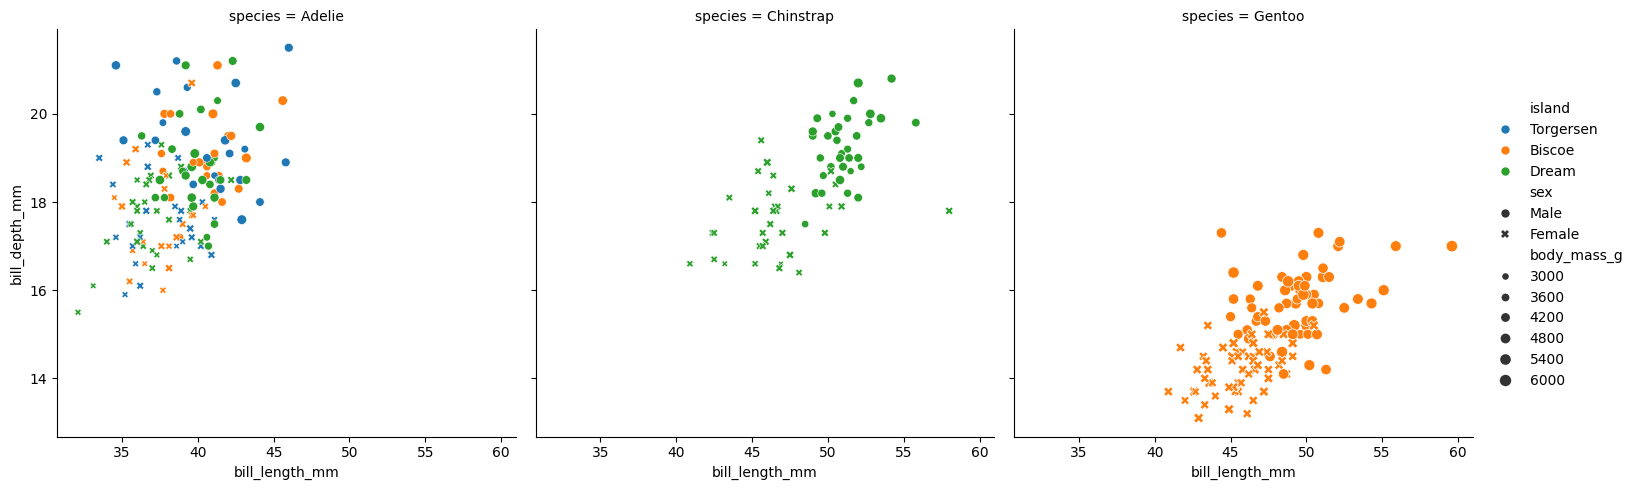

In [22]:
sns.relplot(
    penguin, x="bill_length_mm", y="bill_depth_mm", col="species",
    hue="island", size="body_mass_g", style="sex",
)



OK
           bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
species                                                                 
Adelie               38.8           18.3              190.0       3700.7
Chinstrap            48.8           18.4              195.8       3733.1
Gentoo               47.5           15.0              217.2       5076.0


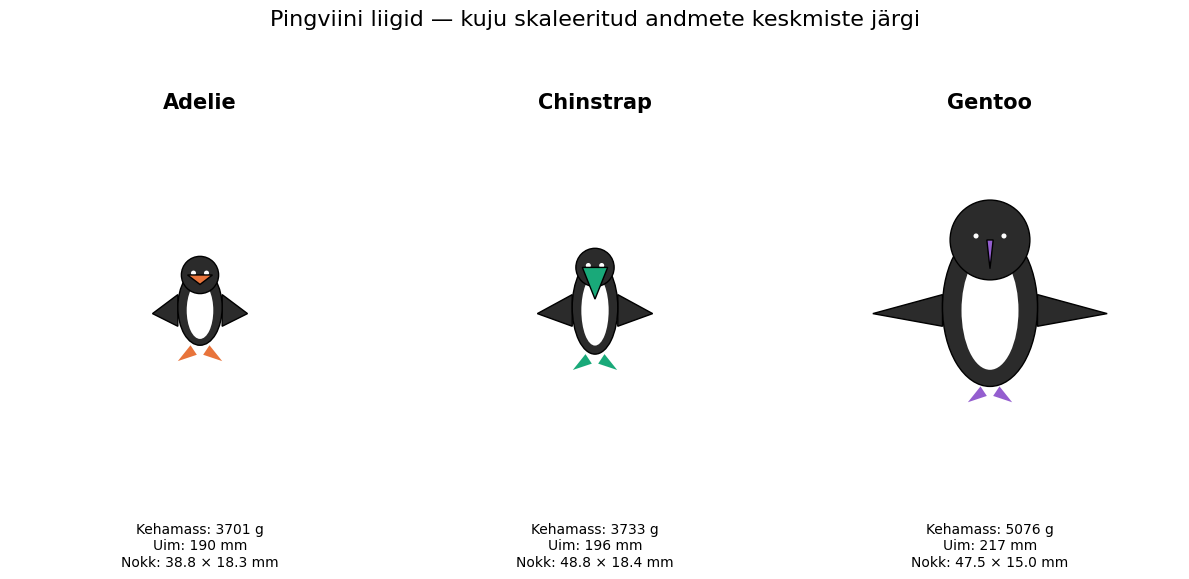

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Polygon
import numpy as np

penguin = sns.load_dataset("penguins")

# Keskmised liigi kaupa
agg = penguin.groupby("species")[
    ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
].mean()

species_list = agg.index.tolist()

# Normaliseeri iga tunnus 0..1, et skaleerida joonist
norm = (agg - agg.min()) / (agg.max() - agg.min())

colors = {"Adelie": "#E8743B", "Chinstrap": "#19A979", "Gentoo": "#945ECF"}

fig, axes = plt.subplots(1, len(species_list), figsize=(4*len(species_list), 6))

for ax, sp in zip(axes, species_list):
    n = norm.loc[sp]
    raw = agg.loc[sp]

    # skaleeritud mõõtmed
    body_h = 1.2 + n["flipper_length_mm"] * 1.3      # keha kõrgus <- uime pikkus
    body_w = 0.7 + n["body_mass_g"] * 0.8            # keha laius  <- kehamass
    bill_len = 0.15 + n["bill_length_mm"] * 0.35     # noka pikkus
    bill_dep = 0.05 + n["bill_depth_mm"] * 0.15      # noka sügavus (paksus)
    flip_len = 0.4 + n["flipper_length_mm"] * 0.7    # uime pikkus

    cx, cy = 0, 0
    c = colors.get(sp, "#555")

    # Keha (must ellips)
    ax.add_patch(Ellipse((cx, cy), body_w, body_h, facecolor="#2b2b2b", edgecolor="black", zorder=2))
    # Kõht (valge)
    ax.add_patch(Ellipse((cx, cy-0.05), body_w*0.6, body_h*0.75, facecolor="white", edgecolor="none", zorder=3))
    # Pea
    head_y = cy + body_h/2 * 0.85
    head_r = body_w*0.42
    ax.add_patch(Ellipse((cx, head_y), head_r*2, head_r*2, facecolor="#2b2b2b", edgecolor="black", zorder=4))
    # Silmad
    ax.add_patch(Ellipse((cx-head_r*0.35, head_y+head_r*0.1), 0.08, 0.08, facecolor="white", zorder=5))
    ax.add_patch(Ellipse((cx+head_r*0.35, head_y+head_r*0.1), 0.08, 0.08, facecolor="white", zorder=5))
    # Nokk (kolmnurk) — pikkus & sügavus andmetest, liigivärv
    beak = Polygon([[cx-bill_dep, head_y], [cx+bill_dep, head_y], [cx, head_y-bill_len]],
                   closed=True, facecolor=c, edgecolor="black", zorder=6)
    ax.add_patch(beak)
    # Uimed (kaks tiiba) — pikkus andmetest
    ax.add_patch(Polygon([[cx-body_w/2, cy+0.2],[cx-body_w/2-flip_len,cy-0.1],[cx-body_w/2, cy-0.3]],
                         closed=True, facecolor="#2b2b2b", edgecolor="black", zorder=1))
    ax.add_patch(Polygon([[cx+body_w/2, cy+0.2],[cx+body_w/2+flip_len,cy-0.1],[cx+body_w/2, cy-0.3]],
                         closed=True, facecolor="#2b2b2b", edgecolor="black", zorder=1))
    # Jalad
    ax.add_patch(Polygon([[cx-0.15,cy-body_h/2],[cx-0.35,cy-body_h/2-0.25],[cx-0.05,cy-body_h/2-0.15]],
                         closed=True, facecolor=c, zorder=1))
    ax.add_patch(Polygon([[cx+0.15,cy-body_h/2],[cx+0.35,cy-body_h/2-0.25],[cx+0.05,cy-body_h/2-0.15]],
                         closed=True, facecolor=c, zorder=1))

    # Silt andmetega
    ax.set_title(sp, fontsize=15, fontweight="bold")
    txt = (f"Kehamass: {raw['body_mass_g']:.0f} g\n"
           f"Uim: {raw['flipper_length_mm']:.0f} mm\n"
           f"Nokk: {raw['bill_length_mm']:.1f} × {raw['bill_depth_mm']:.1f} mm")
    ax.text(0, -3.4, txt, ha="center", va="top", fontsize=10)

    ax.set_xlim(-3, 3)
    ax.set_ylim(-4, 3)
    ax.set_aspect("equal")
    ax.axis("off")

fig.suptitle("Pingviini liigid — kuju skaleeritud andmete keskmiste järgi", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("penguins_species.png", dpi=130, bbox_inches="tight")
print("OK")
print(agg.round(1))


OK


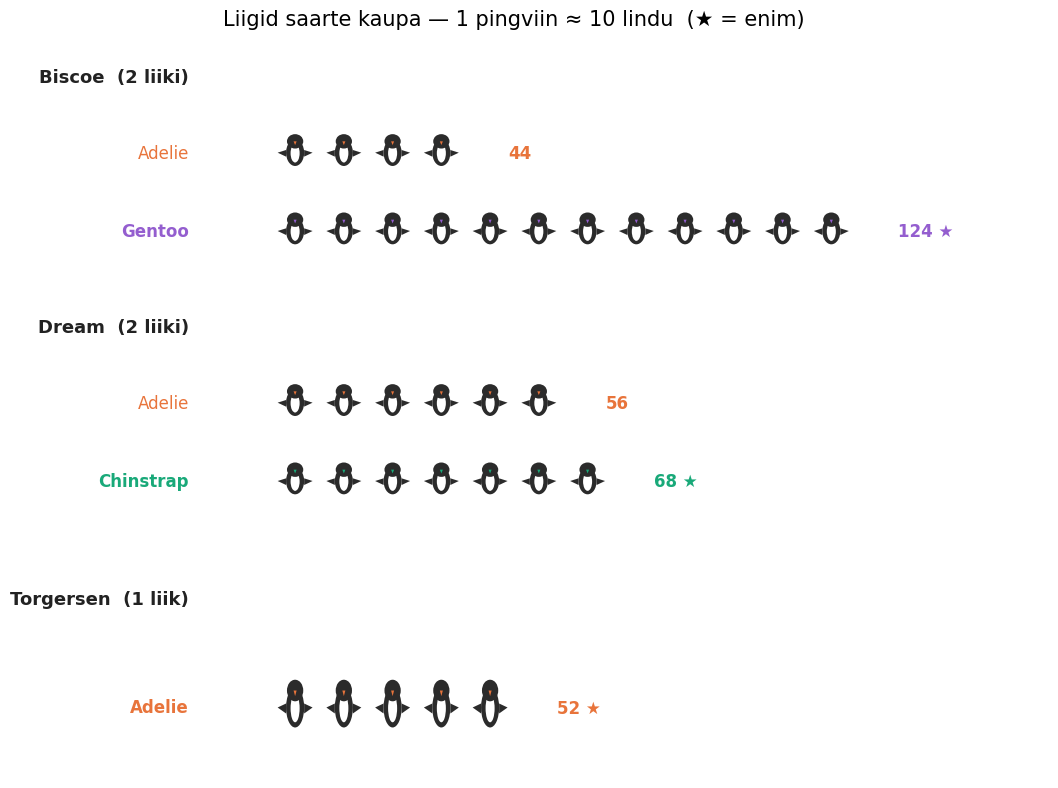

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Polygon
import numpy as np

penguin = sns.load_dataset("penguins")
ct = penguin.groupby(["island", "species"]).size().unstack(fill_value=0)

colors = {"Adelie": "#E8743B", "Chinstrap": "#19A979", "Gentoo": "#945ECF"}
species_order = ["Adelie", "Chinstrap", "Gentoo"]
islands = ct.index.tolist()
PER_ICON = 10

def mini_penguin(ax, cx, cy, c, s=0.34):
    bw, bh = 0.6*s, 1.0*s
    ax.add_patch(Ellipse((cx, cy), bw, bh, facecolor="#2b2b2b", edgecolor="none", zorder=2))
    ax.add_patch(Ellipse((cx, cy-0.02*s), bw*0.5, bh*0.7, facecolor="white", zorder=3))
    hr = bw*0.45; hy = cy + bh/2*0.85
    ax.add_patch(Ellipse((cx, hy), hr*2, hr*2, facecolor="#2b2b2b", edgecolor="none", zorder=4))
    ax.add_patch(Polygon([[cx-0.05*s,hy],[cx+0.05*s,hy],[cx,hy-0.14*s]], closed=True,
                         facecolor=c, edgecolor="none", zorder=6))
    ax.add_patch(Polygon([[cx-bw/2,cy+0.1*s],[cx-bw/2-0.28*s,cy],[cx-bw/2,cy-0.15*s]], closed=True,
                         facecolor="#2b2b2b", zorder=1))
    ax.add_patch(Polygon([[cx+bw/2,cy+0.1*s],[cx+bw/2+0.28*s,cy],[cx+bw/2,cy-0.15*s]], closed=True,
                         facecolor="#2b2b2b", zorder=1))

fig, axes = plt.subplots(len(islands), 1, figsize=(11, 8))

for ax, isl in zip(axes, islands):
    row = ct.loc[isl]
    present = [s for s in species_order if row[s] > 0]
    winner = row.idxmax()
    y = 0
    for sp in present:
        cnt = row[sp]
        icons = int(round(cnt / PER_ICON))
        for i in range(icons):
            mini_penguin(ax, i*0.55, y, colors[sp])
        star = " ★" if sp == winner else ""
        ax.text(-1.2, y, f"{sp}", ha="right", va="center", fontsize=12,
                fontweight="bold" if sp==winner else "normal", color=colors[sp])
        ax.text(icons*0.55 + 0.2, y, f"{cnt}{star}", ha="left", va="center",
                fontsize=12, fontweight="bold", color=colors[sp])
        y -= 1.0

    n_species = len(present)
    ax.text(-1.2, 0.85, f"{isl}  ({n_species} liik{'i' if n_species>1 else ''})",
            ha="right", va="bottom", fontsize=13, fontweight="bold", color="#222")
    ax.set_xlim(-3.2, 8.5)
    ax.set_ylim(y+0.4, 1.4)
    ax.axis("off")

fig.suptitle(f"Liigid saarte kaupa — 1 pingviin \u2248 {PER_ICON} lindu  (★ = enim)",
             fontsize=15, y=0.98)
plt.tight_layout()
plt.savefig("penguins_islands_picto.png", dpi=130, bbox_inches="tight")
print("OK")

<Axes: xlabel='body_mass_g', ylabel='species'>

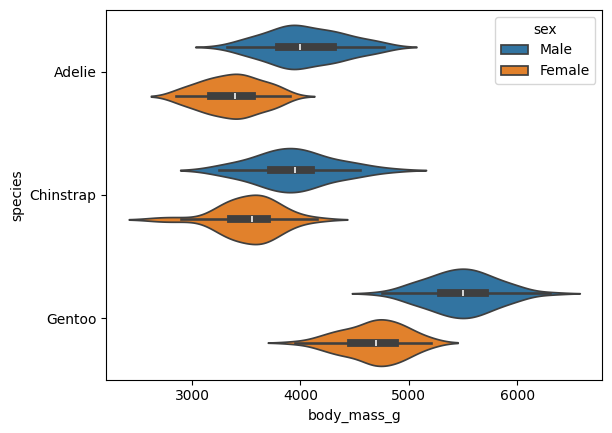

In [27]:
sns.violinplot(penguin, x="body_mass_g", y="species", hue="sex")

In [47]:
def penguin_plot(tunnus: str):
    print(f"Graafikul on {tunnus}")
    sns.violinplot(penguin, x=tunnus, y="species", hue="sex")


Graafikul on body_mass_g


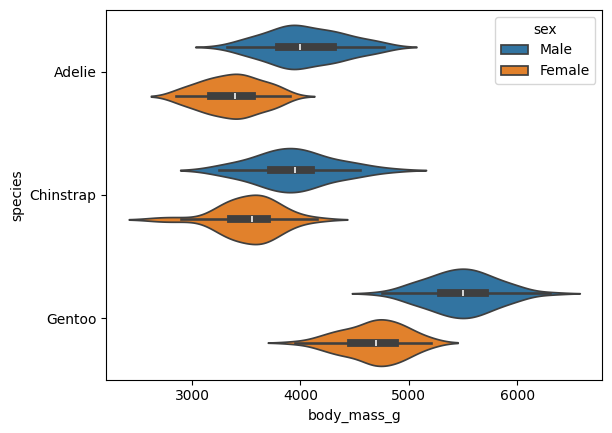

In [48]:
penguin_plot("body_mass_g")

Graafikul on flipper_length_mm


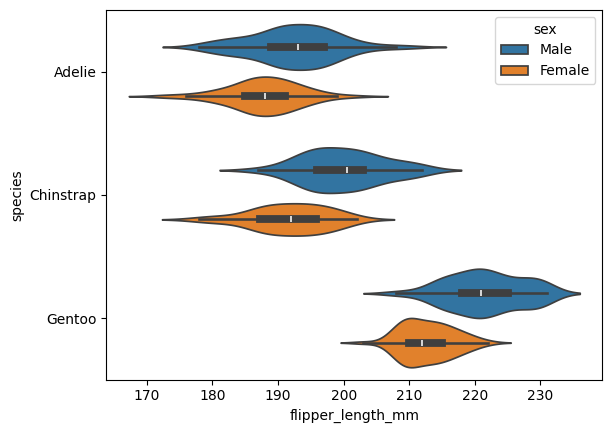

In [39]:
penguin_plot("flipper_length_mm")

In [50]:
duplicate(5)
# 10

NameError: name 'duplicate' is not defined

In [51]:
duplicate(30)
# 60

NameError: name 'duplicate' is not defined

## Duckdb ehk saame partidega sina peale

In [58]:
duckdb.sql("""
    SELECT 'Hello, world!'
""")

┌─────────────────┐
│ 'Hello, world!' │
│     varchar     │
├─────────────────┤
│ Hello, world!   │
└─────────────────┘

In [59]:
duckdb.sql("""
    SELECT 'Hello, world!'
""").df()

,"'Hello, world!'"
0,"Hello, world!"


In [73]:
duckdb.sql("""
    SELECT *
    FROM 'iris.csv'
""").df()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [74]:
duckdb.sql("""
    SELECT *
    FROM penguin
""").df()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,None
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,None
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [75]:
adelia_penguins_from_torgersen_island = duckdb.sql("""
    SELECT *
    FROM penguin
    WHERE species = 'Adelie' AND island = 'Torgersen'
""").df()
adelia_penguins_from_torgersen_island

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,None
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,Female
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,Male
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,None
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,None


<Axes: xlabel='body_mass_g', ylabel='sex'>

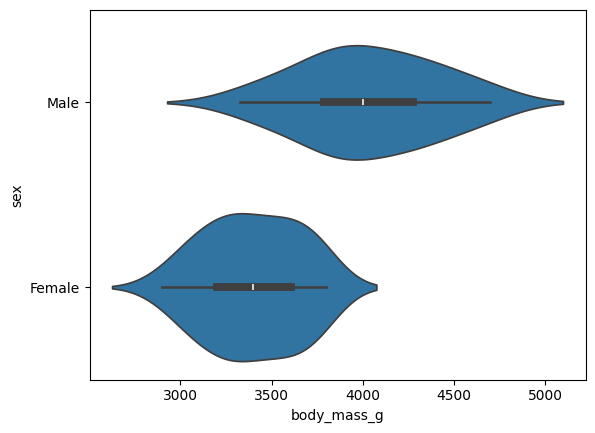

In [79]:
sns.violinplot(adelia_penguins_from_torgersen_island, y="sex", x="body_mass_g")

In [83]:

duckdb.sql("""
    SELECT DISTINCT species
    FROM penguin
""")

┌───────────┐
│  species  │
│  varchar  │
├───────────┤
│ Adelie    │
│ Gentoo    │
│ Chinstrap │
└───────────┘

In [84]:
duckdb.sql("""
    SELECT
        body_mass_g,
        sex,
        CASE species 
            WHEN 'Adelie' THEN 'kollane'
            WHEN 'Gentoo' THEN 'roheline'
            WHEN 'Chinstrap' THEN 'roosa'
        END AS color
    FROM penguin
    WHERE species = 'Adelie' AND island = 'Torgersen'
    LIMIT 10
""")

┌─────────────┬─────────┬─────────┐
│ body_mass_g │   sex   │  color  │
│   double    │ varchar │ varchar │
├─────────────┼─────────┼─────────┤
│      3750.0 │ Male    │ kollane │
│      3800.0 │ Female  │ kollane │
│      3250.0 │ Female  │ kollane │
│        NULL │ NULL    │ kollane │
│      3450.0 │ Female  │ kollane │
│      3650.0 │ Male    │ kollane │
│      3625.0 │ Female  │ kollane │
│      4675.0 │ Male    │ kollane │
│      3475.0 │ NULL    │ kollane │
│      4250.0 │ NULL    │ kollane │
├─────────────┴─────────┴─────────┤
│ 10 rows               3 columns │
└─────────────────────────────────┘

## Pingviini tiitli ennustamise mudel

### Viskame andmetest välja puuduvad väärtused

In [92]:
penguin

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,test_train
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,0
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,1
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,0
...,...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN,0
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female,0
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male,1
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female,0


In [130]:
import pandas as pd

complete_penguins = pd.get_dummies(penguin.dropna().copy(), columns=["species", "sex"], drop_first=True)
complete_penguins['sex'] = complete_penguins['sex_Male'].astype(int)
complete_penguins.pop("sex_Male")
complete_penguins

,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,test_train,species_Chinstrap,species_Gentoo,sex
0,Torgersen,39.1,18.7,181.0,3750.0,0,False,False,1
1,Torgersen,39.5,17.4,186.0,3800.0,0,False,False,0
2,Torgersen,40.3,18.0,195.0,3250.0,0,False,False,0
4,Torgersen,36.7,19.3,193.0,3450.0,0,False,False,0
5,Torgersen,39.3,20.6,190.0,3650.0,1,False,False,1
...,...,...,...,...,...,...,...,...,...
338,Biscoe,47.2,13.7,214.0,4925.0,0,False,True,0
340,Biscoe,46.8,14.3,215.0,4850.0,0,False,True,0
341,Biscoe,50.4,15.7,222.0,5750.0,1,False,True,1
342,Biscoe,45.2,14.8,212.0,5200.0,0,False,True,0


### *Train-test split*

In [131]:
np.random.seed(42)

n_samples = len(complete_penguins)
n_test = int(0.3 * n_samples)
split_flags = np.zeros(n_samples, dtype=int)
test_indices = np.random.choice(n_samples, size=n_test, replace=False)
split_flags[test_indices] = 1

complete_penguins["test_train"] = split_flags
complete_penguins

,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,test_train,species_Chinstrap,species_Gentoo,sex
0,Torgersen,39.1,18.7,181.0,3750.0,0,False,False,1
1,Torgersen,39.5,17.4,186.0,3800.0,0,False,False,0
2,Torgersen,40.3,18.0,195.0,3250.0,0,False,False,0
4,Torgersen,36.7,19.3,193.0,3450.0,1,False,False,0
5,Torgersen,39.3,20.6,190.0,3650.0,0,False,False,1
...,...,...,...,...,...,...,...,...,...
338,Biscoe,47.2,13.7,214.0,4925.0,0,False,True,0
340,Biscoe,46.8,14.3,215.0,4850.0,0,False,True,0
341,Biscoe,50.4,15.7,222.0,5750.0,1,False,True,1
342,Biscoe,45.2,14.8,212.0,5200.0,0,False,True,0


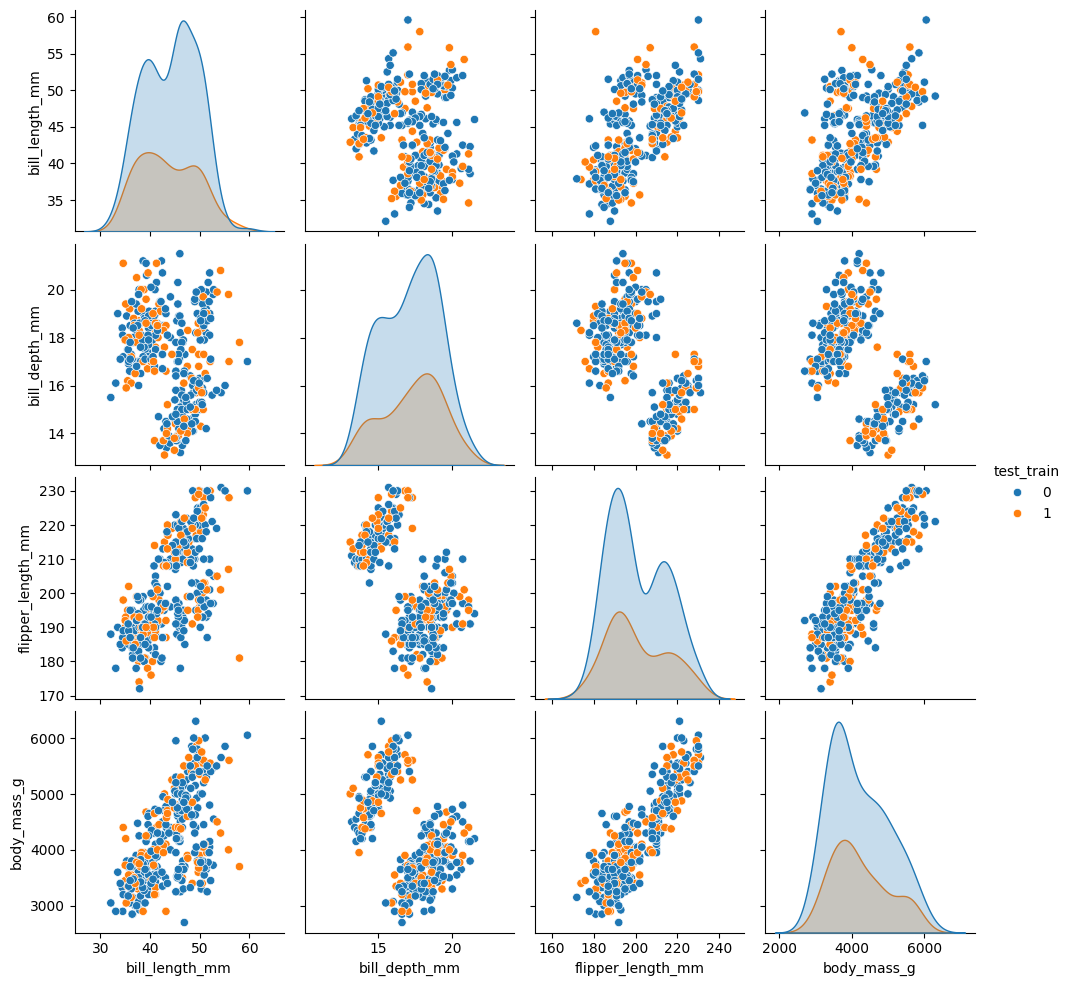

In [98]:
sns.pairplot(complete_penguins, hue="test_train")

### Mudeli treenimine

In [132]:
complete_penguins.columns

Index(['island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm',
       'body_mass_g', 'test_train', 'species_Chinstrap', 'species_Gentoo',
       'sex'],
      dtype='object')

In [133]:
train_data = complete_penguins[complete_penguins["test_train"] == 0]
test_data = complete_penguins[complete_penguins["test_train"] == 1]

print(len(train_data), len(test_data))

234 99


In [134]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(
    train_data[['species_Chinstrap', 'species_Gentoo','bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']],
    train_data["sex"]
)

RandomForestClassifier()

### Mudeli headuse hindamine

In [135]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

penguin_gender_prediction = model.predict(test_data[['species_Chinstrap', 'species_Gentoo','bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']])
penguin_gender_prediction

array([0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1])

In [136]:
matrix = confusion_matrix(test_data['sex'], penguin_gender_prediction)
matrix

array([[44,  4],
       [ 4, 47]])

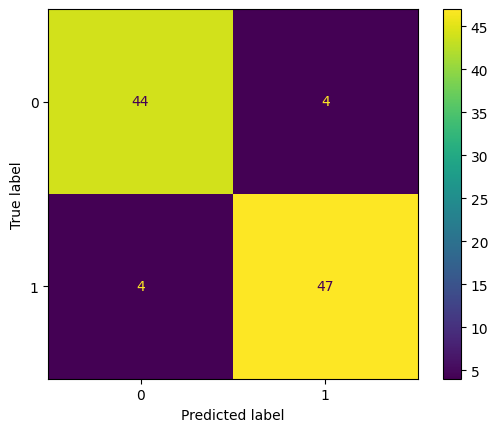

In [137]:
import matplotlib.pyplot as plt
ConfusionMatrixDisplay.from_predictions(test_data['sex'], penguin_gender_prediction)
plt.show()

### Aga miks mudel nii arvab?

In [146]:
import shap

explainer = shap.TreeExplainer(model)
explanation = explainer(test_data[['species_Chinstrap', 'species_Gentoo','bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']])

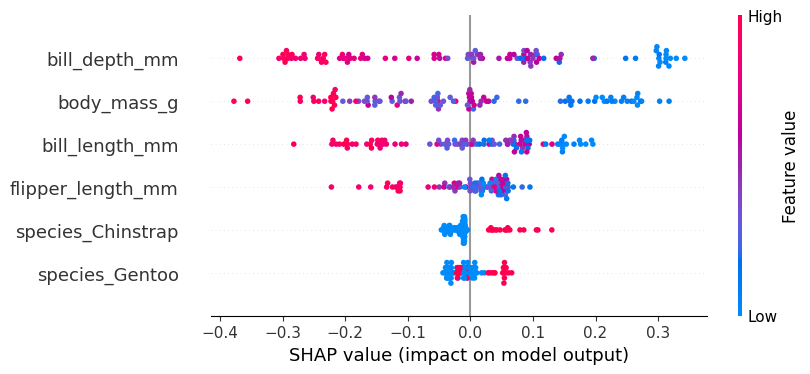

In [147]:
shap.plots.beeswarm(explanation[:,:,0])
